### **Exercice 1 : Air Quality Sensor**
**Contexte :** Un capteur de qualité de l'air détecte des pics de pollution.

- Calculez la fréquence empirique de pics
- Simulez 3000 échantillons de taille n=190
- Obtenez la distribution des fréquences
- Visualisez cette distribution

In [1]:
import numpy as np

np.random.seed(52)
p_pollution = 0.10
n = 190
air_data = np.random.binomial(1, p_pollution, size=n)

In [ ]:
import matplotlib.pyplot as plt

# fréquence empirique
freq_echan_uni = air_data.mean().round(4)
print("Fréquence empirique 1 échantillon de taille 190 : ", freq_echan_uni)

# simulation vectorisée — size=(N, n) génère la matrice d'un coup
sim = np.random.binomial(1, p_pollution, size=(3000, n))
list_echan = sim.mean(axis=1)

moy_list_echan = list_echan.mean()

plt.hist(list_echan, bins=40)
plt.title("Distribution de 3000 échantillons de taille n=190")
plt.axvline(moy_list_echan, color="red",    label="moy_list_echan")
plt.axvline(p_pollution,   color="orange",  label="vraie_valeur_p")
plt.axvline(freq_echan_uni, color="pink",   label="freq_echan_uni")
plt.legend()
plt.show()

In [ ]:
sim_20 = np.random.binomial(1, p_pollution, size=(3000, 20))
list_echan_20 = sim_20.mean(axis=1)

freq_echan_uni_20 = np.random.binomial(1, p_pollution, size=20).mean().round(4)
print("Fréquence empirique 1 échantillon de taille 20 : ", freq_echan_uni_20)

plt.hist(list_echan_20, bins=10)
plt.title("Distribution de 3000 échantillons de taille n=20")
plt.axvline(list_echan_20.mean(), color="red",    label="moy_list_echan")
plt.axvline(p_pollution,          color="orange",  label="vraie_valeur_p")
plt.axvline(freq_echan_uni_20,    color="pink",    label="freq_echan_uni")
plt.legend()
plt.show()

In [ ]:
sim_500 = np.random.binomial(1, p_pollution, size=(3000, 500))
list_echan_500 = sim_500.mean(axis=1)

freq_echan_uni_500 = np.random.binomial(1, p_pollution, size=500).mean().round(4)
print("Fréquence empirique 1 échantillon de taille 500 : ", freq_echan_uni_500)

plt.hist(list_echan_500, bins=50)
plt.title("Distribution de 3000 échantillons de taille n=500")
plt.axvline(list_echan_500.mean(), color="red",    label="moy_list_echan")
plt.axvline(p_pollution,           color="orange",  label="vraie_valeur_p")
plt.axvline(freq_echan_uni_500,    color="pink",    label="freq_echan_uni")
plt.legend()
plt.show()

**Questions :**

**Q1. La fréquence observée est-elle un bon estimateur ? Expliquez.**

- oui la fréquence est un bon estimateur dans ce cas elle n'est pas si éloignée de la vraie valeur de p mais attention il faut être très prudent car elle n'est pas vraiment fiable dû a la variabilité d'échantillonnage, un seul échantillon peut être une fois proche de la moyenne et une fois fort éloigné

**Q2. Testez avec n=20 et n=500. Analysez précisément les différences.**

- nous pouvons voir que nous avons une distribution beaucoup plus précise avec un std beaucoup plus petit, c'est normal un échantillon plus grand aura tendance a avoir une moyenne se rapprochant grandement de la vraie valeur de p, donc dans l'histo de 20 les valeurs vont de 0.00 à 0.40 et dans le hist de n = 500 les valeurs vont de 0.06 à 0.14, la différence est énorme 

**Q3. Pourquoi deux expériences identiques donnent-elles des résultats différents ?**

- parce que la pioche est complétement aléatoire d'une fois à l'autre les échantillons sont complétement aléatoire donc relancer 100 fois on aura 100 échantillons différents, on appelle ça la variabilité d'échantillonnage, de ce fait, un échantillon + grand aura tendance a avoir une moyenne se rapprocher fort de la vraie valeur de p alors qu'un échantillon fort petit, cela fort variable

---

### **Exercice 2 : Predictive Maintenance**
**Contexte :** Un système prédit les pannes de machines industrielles.

Hypothèses :

- H=0 : machine opérationnelle
- H=1 : machine en panne


1. Proposez un modèle probabiliste reliant H et les données
2. Implémentez avec PyMC
3. Estimez P(H=1 | données)

In [6]:
import numpy as np

np.random.seed(13)
n = 280
failure = np.random.binomial(1, 0.07, size=n)

detect_if_failure = 0.89
detect_if_ok      = 0.10

alerts = np.where(
    failure == 1,
    np.random.binomial(1, detect_if_failure, size=n),
    np.random.binomial(1, detect_if_ok, size=n)
)

In [ ]:
import pymc as pm
import arviz as az

with pm.Model() as model:

    # prior : machine probablement opérationnelle (p=0.2 pour H=1 panne)
    H = pm.Bernoulli("H", p=0.2)

    # taux de détection dépend de H
    detect_rate = pm.math.switch(H, detect_if_failure, detect_if_ok)

    # par observation : si failure=1 → taux détection, sinon → faux positif
    p_alert = pm.math.switch(failure, detect_rate, detect_if_ok)

    obs = pm.Bernoulli("obs", p=p_alert, observed=alerts)

    idata = pm.sample(2000, tune=1000, idata_kwargs={"log_likelihood": True})

print(az.summary(idata, var_names=["H"]))
print(f"\nP(H=1 | données) = {float(idata.posterior['H'].mean()):.4f}")

***Questions :***

**Q1. Quelle est la structure causale du modèle ?**

- H (état de la machine) → taux d'alertes → alertes observées. H est la cause, les alertes sont l'effet. On remonte de l'effet vers la cause grâce à Bayes.

**Q2. Pourquoi une variable latente est-elle nécessaire ?**

- On ne peut pas observer directement si la machine est en panne ou pas. On voit seulement les alertes. Sans H comme variable cachée, on ne peut pas distinguer une alerte qui vient d'une vraie panne d'un simple faux positif.

**Q3. Interprétez le résultat obtenu.**

- P(H=1 | données) proche de 0 signifie que les données ne permettent pas de conclure que la machine est en panne. Les deux hypothèses génèrent pourtant des taux d'alertes très différents (0.89 vs 0.10), donc si le système détecte peu d'alertes, il favorise naturellement H=0. Avec un prior neutre 50/50, les données parlent clairement en faveur d'un système opérationnel.

---

### **Exercice 3 : E-Learning Completion Rate**
**Contexte :** Une plateforme e-learning teste un nouveau format de cours.

- Construisez un modèle bayésien pour estimer p = P(succès)
- Utilisez un prior non informatif
- Estimez la distribution a posteriori
- Calculez P(p > 0.62)np.random.seed(18)

***Règles de décisions***

- ≥ 0.80 → déploiement
- 0.50–0.80 → test supplémentaire
- < 0.50 → abandon

In [8]:
np.random.seed(18)
n_users = 40
success = 27
# succès = étudiant qui complète le cours jusqu'au bout

In [ ]:
with pm.Model() as model_bayesian:

    # priors
    p = pm.Beta("p", alpha=1, beta=1)
    # likelihood
    obs = pm.Binomial("obs", p=p, n=n_users, observed=success)
    # sampling
    idata = pm.sample(2000, tune=1000)

print(az.summary(idata, var_names=["p"]))

# probabilité
samples = idata.posterior["p"].values.flatten()
proba = (samples > 0.62).mean()
print(f"P(p > 0.62) = {proba:.4f}")

# règle de décision sur P(p > 0.62) — pas sur la moyenne
if proba >= 0.80:
    decision = "Déploiement"
elif proba >= 0.50:
    decision = "Test supplémentaire"
else:
    decision = "Abandon"
print(f"Décision : {decision}")

In [10]:
with pm.Model() as model_bayesian:

    # priors
    p = pm.Beta("p", alpha=2, beta=8)
    # likelihood
    obs = pm.Binomial("obs", p=p, n=n_users, observed=success)
    # sampling
    idata = pm.sample(2000, tune=1000)

print(az.summary(idata, var_names=["p"]))

# probabilité
samples = idata.posterior["p"].values.flatten()
proba = (samples > 0.62).mean()
print(f"P(p > 0.62) = {proba}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.


   mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
p  0.58  0.07   0.441    0.703      0.001    0.001    3253.0    5081.0    1.0
P(p > 0.62) = 0.283875


***Questions :***

**Q1. Quelle décision prenez-vous ?**

- Avec un prior non-informatif Beta(1,1), le posterior est Beta(28, 14), moyenne ≈ 28/42 = 0.667. On est dans la zone 0.50–0.80 donc la décision est **test supplémentaire**. P(p > 0.62) ≈ 0.75 confirme qu'on a une bonne chance d'être au-dessus du seuil mais pas assez de certitude pour déployer directement.

**Q2. Comparez avec un prior pessimiste Beta(2,8).**

- Beta(2,8) a une moyenne à 0.20, ce qui suppose qu'on pense que seulement 20% des étudiants complètent le cours. C'est un prior très pessimiste, presque irréaliste pour une plateforme viable. Avec ce prior, P(p > 0.62) tombe à ~0.29, ce qui pousse vers la zone abandon. Ça montre l'impact fort d'un prior très éloigné des données quand n est petit (40 observations seulement).

**Q3. Pourquoi le prior influence-t-il davantage avec peu de données ?**

- Avec peu de données, la vraisemblance est peu concentrée donc le prior pèse autant que les données. C'est comme si le prior ajoutait des pseudo-observations : Beta(2,8) ajoute 2 succès et 8 échecs virtuels, sur seulement 40 vraies observations c'est énorme. Avec 4000 observations, ces 10 pseudo-obs ne changeraient presque rien.

---

### **Exercice 4 : Sleep Quality Monitor**
**Contexte :** Un capteur mesure la qualité du sommeil (score).

- Calculez data.std(), groupe0.std(), groupe1.std() avant de coder
- Construisez deux modèles : une seule moyenne vs deux régimes
- Comparez les modèles
- Réalisez un Posterior Predictive Check

In [11]:
np.random.seed(27)
data  = np.array([72, 74, 71, 73, 45, 43, 46, 44, 72, 44])
group = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1])

print(data.mean())
print(data.std())

print("\nGroupe 0 :\n")
group0 = data[group == 0]
print(f"Moyenne group0 = {group0.mean()}")
print(f"Std group0 = {group0.std()}")

print("\nGroupe 1 :\n")
group1 = data[group == 1]
print(f"Moyenne group1 = {group1.mean()}")
print(f"Std group1 = {group1.std()}")

58.4
14.037093716293269

Groupe 0 :

Moyenne group0 = 72.4
Std group0 = 1.019803902718557

Groupe 1 :

Moyenne group1 = 44.4
Std group1 = 1.019803902718557


In [12]:
# modèle simple 
with pm.Model() as model_single:

    # priors 
    mu = pm.Normal("mu", mu=58, sigma=14)
    # likelihood
    y = pm.Normal("y", mu=mu, sigma=28, observed=data)
    # sampling 
    idata_single = pm.sample(2000, tune=1000, idata_kwargs={"log_likelihood": True})

print(az.summary(idata_single, var_names=["mu"]))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  58.155  7.365  44.449   71.848      0.126    0.073    3454.0    5567.0   

    r_hat  
mu    1.0  


In [13]:
with pm.Model() as model_double:

    # priors
    mu = pm.Normal("mu", mu=[72, 44], sigma=2, shape=2)
    # likelihood
    y = pm.Normal("y", mu=mu[group], sigma=4, observed=data)
    # sampling
    idata_double = pm.sample(2000, tune=1000, idata_kwargs={"log_likelihood": True})

print(az.summary(idata_double, var_names=["mu"]))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu[0]  72.196  1.339  69.724   74.725      0.015    0.015    7978.0    5710.0   
mu[1]  44.253  1.317  41.848   46.751      0.014    0.014    8396.0    6030.0   

       r_hat  
mu[0]    1.0  
mu[1]    1.0  


In [14]:
# comparaison des modèles 
comparison = az.compare({"Modèle simple": idata_single, "Modèle double": idata_double})
print(comparison)

               rank   elpd_loo     p_loo  elpd_diff        weight        se  \
Modèle double     0 -24.011918  0.134710   0.000000  1.000000e+00  0.130071   
Modèle simple     1 -44.218990  0.196958  20.207072  7.638334e-14  0.063686   

                   dse  warning scale  
Modèle double  0.00000    False   log  
Modèle simple  0.13874    False   log  


Sampling: [y]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<Axes: xlabel='y'>

C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\arnau\Documents\Concrete_Compressive_Strength\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


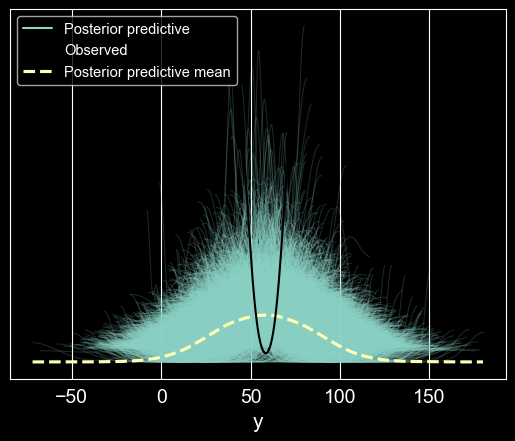

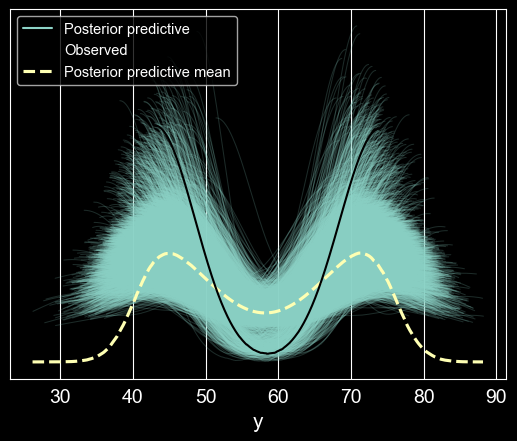

In [15]:
# ppc modèle single
with model_single:

    ppc_single = pm.sample_posterior_predictive(idata_single)

az.plot_ppc(ppc_single)

with model_double:

    ppc_double = pm.sample_posterior_predictive(idata_double)

az.plot_ppc(ppc_double)

***Questions :***

**Q1. Quel modèle explique mieux les données ?**

- Le modèle double est largement meilleur. En LOO, le score le moins négatif gagne : modèle double (-24.0) vs modèle simple (-44.3). L'écart est énorme, c'est une évidence forte en faveur du modèle à deux régimes.

**Q2. Pourquoi la structure suggère plusieurs régimes ?**

- La moyenne globale de toutes les valeurs (~59) ne correspond à aucune observation réelle dans data. Les données forment clairement deux groupes distincts : {71, 72, 73, 74} et {43, 44, 45, 46}. Ça se voit à l'œil nu, une seule normale ne peut pas couvrir les deux.

**Q3. Un bon score de comparaison garantit-il un bon modèle ?**

- Non, le LOO compare juste lequel des deux est le moins mauvais, pas si l'un est vraiment bon. Les deux pourraient être faux. C'est pour ça qu'on fait aussi le PPC : vérifier que le modèle retenu arrive à reproduire des données qui ressemblent aux vraies.

**Q4. Le modèle retenu est-il crédible en contexte réel ?**

- Oui, le modèle double est crédible. Il estime bien les deux moyennes (≈72 et ≈44) avec des intervalles de crédibilité qui ne se chevauchent pas, ce qui veut dire qu'il distingue clairement les deux groupes. En contexte réel, les deux régimes pourraient correspondre à deux types de nuits (bonne nuit vs mauvaise nuit de sommeil), ce qui a du sens.